In [7]:
""" Problem 8.2.3 """

import matplotlib.pyplot as plt
import numpy as np
from scipy import signal as sig
from math import pi, exp, cos, sin, log, log10, sqrt
from control import margin
from scipy.signal import lsim

<>:25: SyntaxWarning: invalid escape sequence '\o'
<>:25: SyntaxWarning: invalid escape sequence '\o'
C:\Users\gjsta\AppData\Local\Temp\ipykernel_11028\2852932458.py:25: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$\omega$ (rad/s)')


Text(770, -47.5, '$\\mathdefault{8.50\\times10^{2}}$')

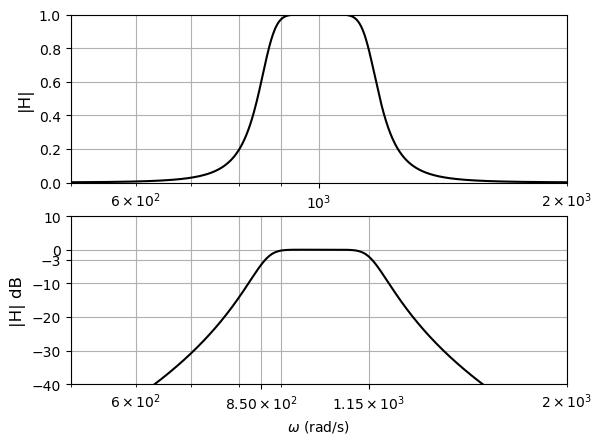

In [9]:
n4 = [8.1e9,0,0,0,0]
da = [1,554,2.09e6,5.54e8,1e12]
db = [1,230,2.09e6,2.3e8,1e12]
d4 = np.convolve(da,db)

num = n4
den = d4

w = np.linspace(500,2000,1000)
system = sig.lti(num,den)
w, Hmag, Hphase = sig.bode(system,w)
gm, pm, wg, wp = margin(Hmag,Hphase,w)

plt.subplot(211)
plt.semilogx(w,10**(0.05*Hmag),'k') # Plot amplitude, not dB.
plt.axis([ 500, 2000, 0, 1])
plt.ylabel('|H|',size = 12)
plt.grid(which='both')

plt.subplot(212)
plt.semilogx(w,Hmag,'k')
plt.axis([ 500, 2000, -40, 10])
plt.ylabel('|H| dB',size = 12)
plt.grid(which='both')
plt.xlabel('$\omega$ (rad/s)')
plt.xticks([850, 1150])
plt.yticks([-40,-30,-20,-10,-3,0,10])
plt.text(770,-47.5,'$\\mathdefault{8.50\\times10^{2}}$')

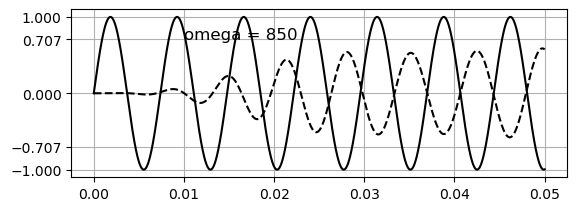

In [25]:
""" Problem 8.2.4 """

omega = 850
t = np.linspace(0, .05, 10000) #If omega is big, make second parameter really small
u = np.sin(omega*t)

tout, yout, xout = lsim((num,den), U=u, T=t)

plt.subplot(211)
plt.plot(t, u, 'k-')
plt.yticks([-1,-.707,0,.707,1])
plt.plot(tout, yout, 'k--')
plt.text(.01,.707,'omega = {}'.format(round(omega,1)),fontsize=12)
plt.grid()
plt.show()